# Exploratory Data Analysis — Frozen Email Dataset

Explores `frozen_dataset.csv` before modeling: the two label distributions (topic, priority) and their relationship, text length per class, and repeated subject templates that motivate a grouped-by-subject split. Sections marked *optional* go beyond the report.

## 1 — Imports and configuration

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

INPUT_PATH = Path("../data/processed/frozen_dataset.csv")

TOPIC_ORDER = ["administrative", "course-exam", "event", "deadline-action", "advertisement"]
PRIORITY_ORDER = ["High", "Medium", "Low"]

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 80)

print("Loading:", INPUT_PATH.resolve())

Loading: D:\UniGe\3\NLP\NLP-project\data\processed\frozen_dataset.csv


## 2 — Load the frozen dataset

In [3]:
df = pd.read_csv(INPUT_PATH)

print(f"Shape : {df.shape[0]} rows  x  {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
print("Column types:")
print(df.dtypes.to_string())
print()
# df.head(3)

Shape : 919 rows  x  8 columns
Memory: 6.81 MB

Column types:
id                   object
subject              object
body_plain           object
topic                object
priority             object
text_subject         object
text_body            object
text_subject_body    object



## 3 — Topic distribution (Task A)

Counts per topic with relative percentages, to show the class imbalance.

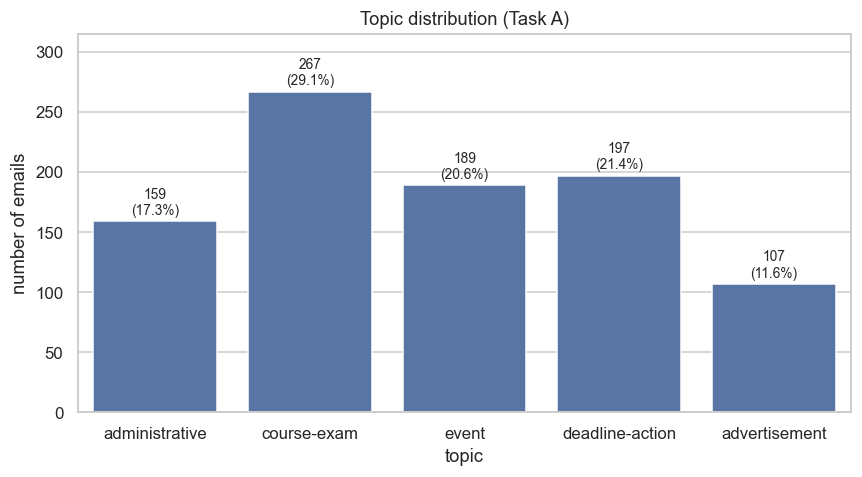

Imbalance ratio (largest / smallest): 2.5


In [ ]:
topic_counts = df["topic"].value_counts().reindex(TOPIC_ORDER)
topic_pct = (topic_counts / topic_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=topic_counts.index, y=topic_counts.values, ax=ax, color="#4C72B0")
ax.set_title("Topic distribution (Task A)")
ax.set_xlabel("topic")
ax.set_ylabel("number of emails")
for i, (count, pct) in enumerate(zip(topic_counts.values, topic_pct.values)):
    ax.text(i, count + 3, f"{count}\n({pct}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, topic_counts.max() * 1.18)
plt.tight_layout()
plt.show()

print("Imbalance ratio (largest / smallest):", round(topic_counts.max() / topic_counts.min(), 2))

## 4 — Priority distribution (Task B)

Counts for the three priority classes (`High`, `Medium`, `Low`).

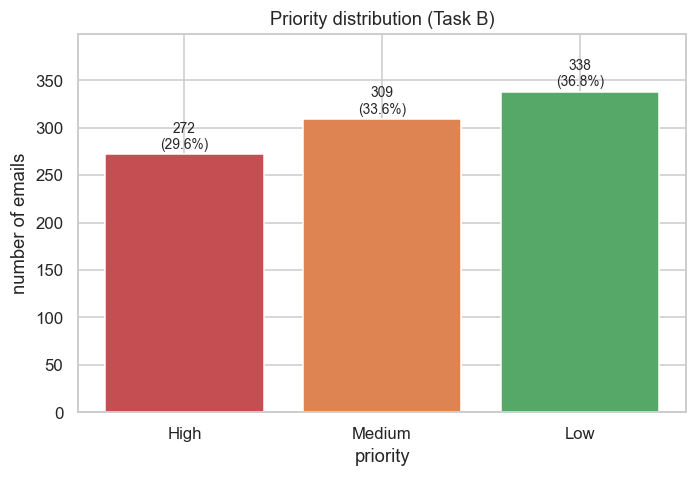

Imbalance ratio (largest / smallest): 1.24


In [ ]:
priority_counts = df["priority"].value_counts().reindex(PRIORITY_ORDER)
priority_pct = (priority_counts / priority_counts.sum() * 100).round(1)

priority_palette = {"High": "#C44E52", "Medium": "#DD8452", "Low": "#55A868"}
priority_colors = [priority_palette[p] for p in priority_counts.index]

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(priority_counts.index, priority_counts.values, color=priority_colors)
ax.set_title("Priority distribution (Task B)")
ax.set_xlabel("priority")
ax.set_ylabel("number of emails")
for i, (count, pct) in enumerate(zip(priority_counts.values, priority_pct.values)):
    ax.text(i, count + 3, f"{count}\n({pct}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, priority_counts.max() * 1.18)
plt.tight_layout()
plt.show()

print("Imbalance ratio (largest / smallest):", round(priority_counts.max() / priority_counts.min(), 2))

## 5 — Topic × Priority relationship

Two heatmaps: raw counts and row-normalized percentages (priority breakdown within each topic). Shows that the two tasks are related but not identical.

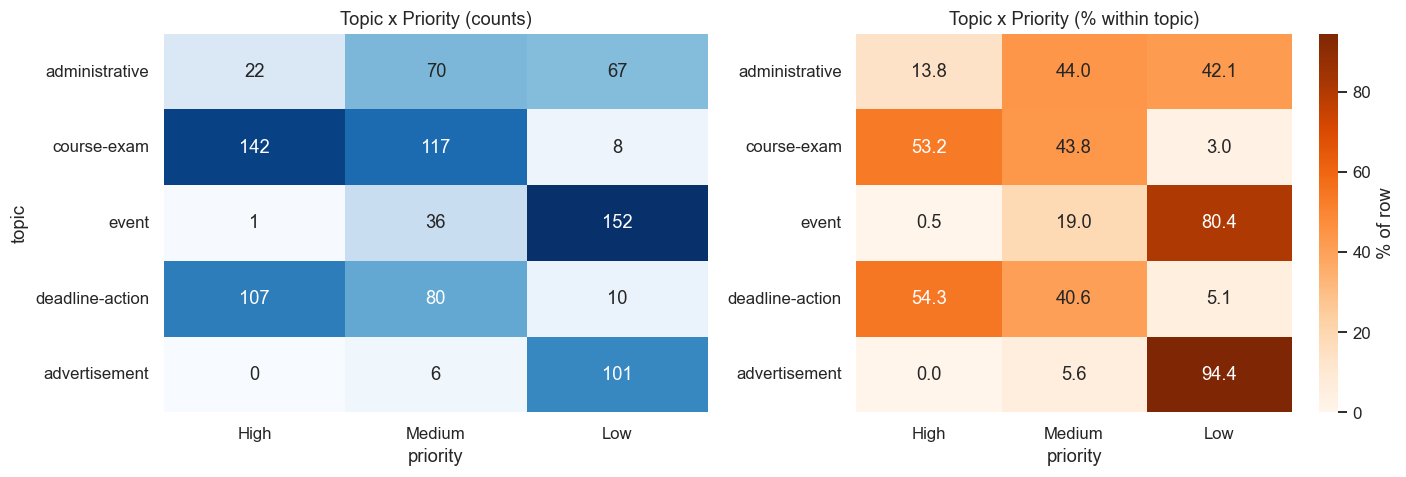

priority,High,Medium,Low
topic,,,
administrative,22,70,67
course-exam,142,117,8
event,1,36,152
deadline-action,107,80,10
advertisement,0,6,101


In [ ]:
cross_counts = (
    pd.crosstab(df["topic"], df["priority"])
    .reindex(index=TOPIC_ORDER, columns=PRIORITY_ORDER)
    .fillna(0)
    .astype(int)
)
cross_row_pct = cross_counts.div(cross_counts.sum(axis=1), axis=0).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(cross_counts, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Topic x Priority (counts)")
axes[0].set_xlabel("priority")
axes[0].set_ylabel("topic")

sns.heatmap(cross_row_pct, annot=True, fmt=".1f", cmap="Oranges", cbar_kws={"label": "% of row"}, ax=axes[1])
axes[1].set_title("Topic x Priority (% within topic)")
axes[1].set_xlabel("priority")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

cross_counts

## 6 — Text length

Build per-row length (characters and words) for the three text fields. The 7.1 boxplots by class are the report figure; the per-field summary table and histograms below are optional.

In [ ]:
text_cols = ["text_subject", "text_body", "text_subject_body"]

# length_df is reused by the 7.1 boxplots below.
length_df = pd.DataFrame({"id": df["id"], "topic": df["topic"], "priority": df["priority"]})
for col in text_cols:
    s = df[col].fillna("").astype(str)
    length_df[f"{col}_chars"] = s.str.len()
    length_df[f"{col}_words"] = s.str.split().map(len)

# Optional, beyond report scope: per-field length summary table.
length_summary = (
    length_df.drop(columns=["id", "topic", "priority"])
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])
    .round(1)
)
length_summary

,text_subject_chars,text_subject_words,text_body_chars,text_body_words,text_subject_body_chars,text_subject_body_words
count,919.0,919.0,919.0,919.0,919.0,919.0
mean,62.1,8.7,1254.0,189.1,1333.8,199.7
std,28.1,4.1,1148.8,184.7,1154.3,185.4
min,6.0,2.0,0.0,0.0,40.0,6.0
25%,42.0,6.0,578.0,82.0,645.0,90.0
50%,59.0,8.0,916.0,137.0,1000.0,148.0
75%,79.0,11.0,1595.0,234.0,1680.0,246.5
90%,97.0,14.0,2598.4,386.0,2682.4,399.4
99%,158.5,21.8,5307.7,820.2,5401.0,829.6
max,171.0,27.0,13789.0,2382.0,13878.0,2395.0


### 6.1 — Length per class

Word-count boxplots by topic and by priority.

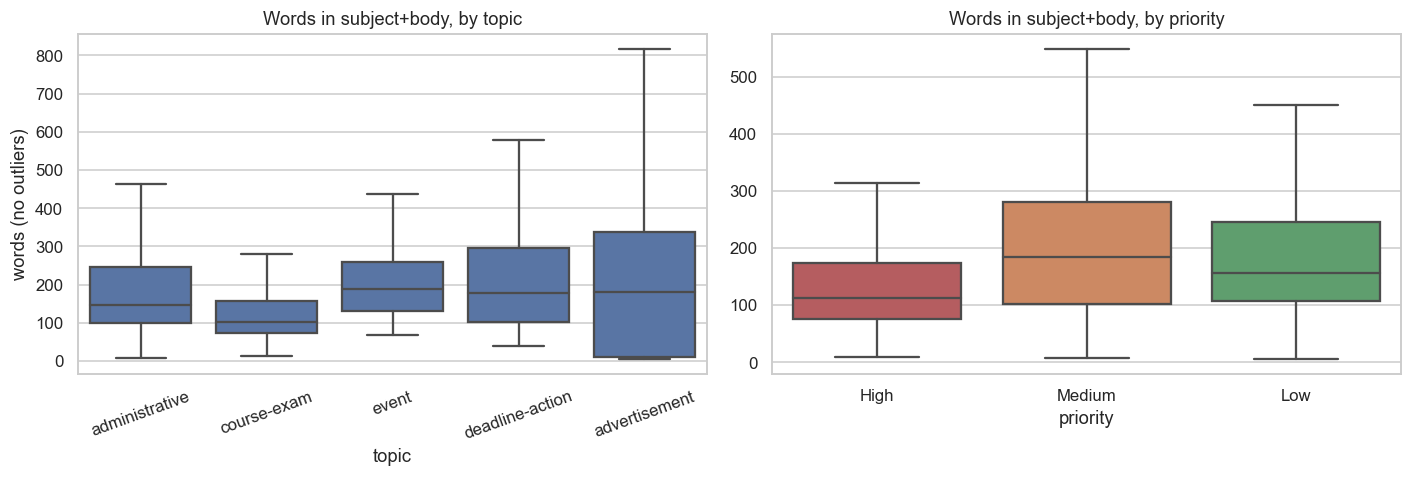

Median words per class — topic:
topic
administrative     148.0
course-exam        101.0
event              188.0
deadline-action    177.0
advertisement      180.0

Median words per class — priority:
priority
High      113.0
Medium    184.0
Low       156.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(
    data=length_df,
    x="topic",
    y="text_subject_body_words",
    order=TOPIC_ORDER,
    ax=axes[0],
    color="#4C72B0",
    showfliers=False,
)
axes[0].set_title("Words in subject+body, by topic")
axes[0].set_ylabel("words (no outliers)")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=length_df,
    x="priority",
    y="text_subject_body_words",
    order=PRIORITY_ORDER,
    palette=priority_palette,
    ax=axes[1],
    showfliers=False,
)
axes[1].set_title("Words in subject+body, by priority")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print("Median words per class — topic:")
print(length_df.groupby("topic")["text_subject_body_words"].median().reindex(TOPIC_ORDER).to_string())
print("\nMedian words per class — priority:")
print(length_df.groupby("priority")["text_subject_body_words"].median().reindex(PRIORITY_ORDER).to_string())

## 7 — Repeated subject templates

University inboxes contain many templated subjects. If the same subject appears in both train and test, a random split is overly optimistic, which motivates a grouped-by-subject split. Here we measure how many emails belong to repeated-subject groups.

In [ ]:
subject_counts = (
    df["text_subject"].fillna("").str.strip().replace("", np.nan).dropna().value_counts()
)
n_unique = subject_counts.shape[0]
n_repeated = int((subject_counts > 1).sum())
n_emails_in_repeated = int(subject_counts[subject_counts > 1].sum())

print(f"Unique non-empty subjects   : {n_unique}")
print(f"Subjects appearing >1 times : {n_repeated}")
print(f"Emails living in such groups: {n_emails_in_repeated} "
      f"({n_emails_in_repeated / len(df) * 100:.1f}% of all rows)")

top_subjects = subject_counts.head(15).rename("count").to_frame()
top_subjects.index.name = "text_subject"
top_subjects

Unique non-empty subjects   : 775
Subjects appearing >1 times : 62
Emails living in such groups: 206 (22.4% of all rows)


,count
text_subject,
[studenti] mercoledi' scienza,25
re: about the auk,10
prenotazione esame,8
nuove scelte personalizzate solo per te!,8
universita' degli studi di genova - registrazione esame,7
re: auk activity: drl,6
scopri le nostre ultime offerte ora!,6
esito esame,6
aulaweb2024 80412: ri: exam 16/7,5


In [ ]:
# === APPENDIX (optional, beyond report scope): label purity within repeated-subject groups ===
def label_purity(group: pd.DataFrame, col: str) -> float:
    """Fraction of the group that carries the most frequent label in `col`."""
    return group[col].value_counts(normalize=True).iloc[0]


repeated_subjects = subject_counts[subject_counts > 1].index
purity_rows = []
for subj in repeated_subjects[:15]:
    sub = df[df["text_subject"] == subj]
    purity_rows.append(
        {
            "subject (truncated)": subj[:70] + ("..." if len(subj) > 70 else ""),
            "n_emails": len(sub),
            "topic_purity": round(label_purity(sub, "topic"), 2),
            "dominant_topic": sub["topic"].mode().iloc[0],
            "priority_purity": round(label_purity(sub, "priority"), 2),
            "dominant_priority": sub["priority"].mode().iloc[0],
        }
    )

pd.DataFrame(purity_rows)

,subject (truncated),n_emails,topic_purity,dominant_topic,priority_purity,dominant_priority
0,[studenti] mercoledi' scienza,25,1.00,event,1.00,Low
1,re: about the auk,10,0.80,course-exam,0.60,Medium
2,prenotazione esame,8,1.00,course-exam,0.75,High
3,nuove scelte personalizzate solo per te!,8,1.00,advertisement,1.00,Low
4,universita' degli studi di genova - registrazione esame,7,0.86,course-exam,1.00,Medium
5,re: auk activity: drl,6,1.00,course-exam,0.50,High
6,scopri le nostre ultime offerte ora!,6,1.00,advertisement,1.00,Low
7,esito esame,6,1.00,course-exam,1.00,High
8,aulaweb2024 80412: ri: exam 16/7,5,1.00,course-exam,0.80,Medium
9,non hai trovato il prodotto high-tech adatto a te?,4,1.00,advertisement,1.00,Low


## 8 — Body-level duplicates

How many rows share an identical cleaned body.

In [ ]:
# === APPENDIX (optional, beyond report scope): body-level duplicate analysis ===
body_series = df["text_body"].fillna("").astype(str)

body_counts = body_series[body_series.str.strip() != ""].value_counts()
body_dups = body_counts[body_counts > 1]

print(f"Non-empty bodies           : {(body_series.str.strip() != '').sum()}")
print(f"Unique non-empty bodies    : {body_counts.shape[0]}")
print(f"Bodies with >1 occurrences : {body_dups.shape[0]}")
print(f"Emails living in body dups : {int(body_dups.sum())} "
      f"({body_dups.sum() / len(df) * 100:.1f}% of rows)")

if not body_dups.empty:
    print("\nTop 5 duplicated bodies (preview):")
    for body, count in body_dups.head(5).items():
        preview = body[:100].replace("\n", " ")
        print(f"  x{count}  | {preview}...")

Non-empty bodies           : 874
Unique non-empty bodies    : 852
Bodies with >1 occurrences : 13
Emails living in body dups : 35 (3.8% of rows)

Top 5 duplicated bodies (preview):
  x5  | annulla l'iscrizione | gestione preferenze | informativa sulla privacy lenovo si riserva il diritto ...
  x4  | gentile studentessa, gentile studente, si ricorda che fino al 15 dicembre p.v. è possibile partecipa...
  x3  | cari studenti, vi ricordiamo che martedì 20 maggio p.v. alle ore 12.00 scade il bando di selezione p...
  x3  | stai frequentando un corso di laurea magistrale e vuoi perfezionarti nel project management delle gr...
  x3  | area legale e generale - servizio affari giuridici e istituzionali settore affari generali e procedi...


## 10 — Vocabulary fingerprint per topic (optional, beyond report scope)

Top discriminating unigrams per topic via a simple log-odds score against the rest of the corpus (words in at least 5 documents).

In [ ]:
# === APPENDIX (optional, beyond report scope): per-topic log-odds top tokens ===
corpus = df["text_subject_body"].fillna("").astype(str).values
labels = df["topic"].values

vectorizer = CountVectorizer(min_df=5, token_pattern=r"(?u)\b[\w'-]{2,}\b")
X = vectorizer.fit_transform(corpus)
vocab = np.array(vectorizer.get_feature_names_out())

class_freq = {}
for cls in TOPIC_ORDER:
    mask = labels == cls
    counts_in = np.asarray(X[mask].sum(axis=0)).ravel()
    counts_out = np.asarray(X[~mask].sum(axis=0)).ravel()
    p_in = (counts_in + 1) / (counts_in.sum() + len(vocab))
    p_out = (counts_out + 1) / (counts_out.sum() + len(vocab))
    log_odds = np.log(p_in) - np.log(p_out)
    class_freq[cls] = pd.Series(log_odds, index=vocab).sort_values(ascending=False)

top_per_topic = pd.DataFrame({cls: class_freq[cls].head(10).index for cls in TOPIC_ORDER})
top_per_topic.index = [f"#{i+1}" for i in range(10)]
top_per_topic

,administrative,course-exam,event,deadline-action,advertisement
#1,quorum,114470,acquario,soddisfazione,lenovo
#2,seggi,lesson,mercoledi,rilevazione,prodotti
#3,ranking,108871,cineversity,scholarships,promozioni
#4,elettorale,90535,auditorium,questionnaire,windows
#5,rappresentanza,commento,fb,survey,thinkvision
#6,cnsu,mock,lucia,compilazione,smarter
#7,collegio,today's,edutainment,universale,logo
#8,programmazione,contents,pusillo,anonima,thinksystem
#9,aggiornata,seems,dell'acquario,esprimere,thinkstation
#10,0102099232,yes,proiezione,all'attività,thinkedge


## 11 — Language proxy (optional, beyond report scope)

Crude English/Italian estimate from small function-word lists, to sense the language mix.

In [ ]:
# === APPENDIX (optional, beyond report scope): language proxy ===
IT_MARKERS = {"il", "la", "lo", "le", "gli", "che", "non", "per", "con",
              "dei", "degli", "delle", "una", "uno", "sono", "essere", "questa",
              "questo", "anche", "come"}
EN_MARKERS = {"the", "and", "for", "with", "this", "that", "from", "have",
              "you", "your", "are", "is", "of", "to", "in", "on", "at",
              "please", "we", "our"}


def language_guess(text: str) -> str:
    tokens = set(text.split())
    it_hits = len(tokens & IT_MARKERS)
    en_hits = len(tokens & EN_MARKERS)
    if it_hits == 0 and en_hits == 0:
        return "unknown"
    if it_hits > en_hits:
        return "it"
    if en_hits > it_hits:
        return "en"
    return "mixed"


df["lang_guess"] = df["text_subject_body"].fillna("").map(language_guess)

print("Language proxy — overall:")
print(df["lang_guess"].value_counts(normalize=True).mul(100).round(1).to_string(), "%")

print("\nLanguage proxy — by topic (% within topic):")
lang_by_topic = (
    pd.crosstab(df["topic"], df["lang_guess"], normalize="index").mul(100).round(1)
)
lang_by_topic.reindex(TOPIC_ORDER)

Language proxy — overall:
lang_guess
it         57.8
en         39.0
mixed       2.6
unknown     0.7 %

Language proxy — by topic (% within topic):


lang_guess,en,it,mixed,unknown
topic,,,,
administrative,37.7,60.4,1.9,0.0
course-exam,70.8,25.5,3.7,0.0
event,18.0,81.5,0.5,0.0
deadline-action,31.5,63.5,5.1,0.0
advertisement,12.1,82.2,0.0,5.6


## 12 — Discussion

Three conclusions for modeling:

1. **Topic is likely easier than priority** — topic labels have clearer lexical patterns, while priority is more contextual (urgency, deadlines, sender).
2. **The two tasks are related but not identical** — topic gives a strong clue about priority, but the same topic appears with different urgency, so they are modeled separately.
3. **Evaluation must control for repeated templates** — about 22% of emails share a repeated subject, so we report both a stratified split and a grouped-by-subject split to avoid overestimating performance.